Bibliotecas usadas

In [2]:
import random
import math
import matplotlib.pyplot as plt
import time

# Letra (A): Entropy e Cross-Entropy

<img src="IMGS/2026 Atividade 1 - Expected values, Surprise, Entropy, Cross-entropy loss, Softmax e True labels .png" width="500">

<img src="IMGS/img2.png" width="500">

<img src="IMGS/img3.png" width="500">

<img src="IMGS/img4.png" width="500">

# Surpresa, Entropia, Cross-Entropy (Teoria)

Os conceitos de **surpresa**, **entropia** e **cross-entropy** são fundamentais para medir incerteza e qualidade de modelos probabilísticos, principalmente em sistemas especialistas (Inteligências Artificiais).

---

## Entropia

A **entropia** mede o nível de incerteza (ou “surpresa média”) de uma variável aleatória.

Definição:

$$
H(P) = - \sum_{i} P(x_i)\,\log P(x_i)
$$

Basicamente se todos os resultados são igualmente prováveis, a incerteza é máxima. Quando um resultado é quase certo, a incerteza é baixa. Ela representa o número médio de bits necessários para codificar um evento.

### Para esse caso em Específico:
- Quando é um dado justo a entropia é alta
- Quando um dado viciado a entropia é baixa  

---

## Cross-Entropy

A **cross-entropy** mede o custo de usar uma distribuição $Q$ para representar a distribuição real $P$.

$$
H(P, Q) = - \sum_{i} P(x_i)\,\log Q(x_i)
$$

#### Variáveis:
- $P$: distribuição verdadeira (realidade)  
- $Q$: distribuição estimada (modelo)

---
A diferença entre Entropy e Cross-Entropy indica o quanto o modelo está deviante.

---

## Ajuste com Decaimento Exponencial

O ajuste por decaimento exponencial corrige um parâmetro em relação a um valor-alvo usando a regra  
$\text{erro}_{\text{novo}} = \text{erro}_{\text{atual}} \cdot e^{-k}$,  

onde \(k > 0\) controla a velocidade da correção. Com $(k = 0{.}3)$, cerca de 26% do erro remanescente é eliminado a cada passo e o restante permanece para próxima operação $(e^{-0,3} \approx 0{.}74)$, garantindo uma convergência suave e progressiva.

In [3]:
# Configurações Iniciais

# Distribuição de Probabilidade do dado Viciado (P)
probabilidade_P = [0.25, 0.125, 0.125, 0.125, 0.125, 0.25]
# Distribuição do Modelo (Q)
probabilidade_Q = [1/6] * 6
# Lados do Dado(6 deles)
lados = [1, 2, 3, 4, 5, 6]

In [4]:
# Entropia e Entropia Cruzada:
def entropy(P, Key):
    if Key == "Vetor":
        return -(sum(Px * math.log2(Px) for Px in P if Px > 0))
    elif Key == "Matriz":
        return sum(entropy(linha, "Vetor") for linha in P) / len(P)
# Problemas com log e log2 em ambas as funções
def cross_entropy(P, Q):
    N = len(P)
    return -(sum(P[i] * math.log(Q[i]) for i in range(N)))

In [5]:
# Ensaio de Jogadas do Dado:
def jogada_dado(P, N=100):
    jogada = random.choices(lados, weights=P, k=N)
    contagem = [jogada.count(i) for i in lados]
    frequencia = [C/N for C in contagem]
    return frequencia

# Ajuste usando Decaimento Exponencial (DE):
def ajuste_DE(P, k = 0.3):
    objetivo = 1/6 # Valor que é para se aproximar a distribuição real

    erro1 = P[0] - objetivo # Dado: Lado 1
    erro2 = P[5] - objetivo # Dado: Lado 6

    P[0] = objetivo + (erro1 * math.exp(-k)) # Ajustando o valor no lado 1
    P[5] = objetivo + (erro2 * math.exp(-k)) # Ajustando o valor do lado 6

    resto = 1 - (P[0] + P[5])
    for i in range(1,5):
        P[i] = resto/4

    return P

# Função de Exibição dos Valores
def simulacao(P, Q, I=10):
    print(f"{'Iteração':<10} {'H(P)':<10} {'H(P,Q)':<10} {'Diferença':<14} {'P(1)':<10} {'P(6)':<10}")
    for i in range(I):

        P_real = jogada_dado(P)

        Entropia = entropy(P, "Vetor")
        Entropia_Cruzada = cross_entropy(P, Q) # Medir o custo
        discrepancia = Entropia - Entropia_Cruzada  # Diferença de Entropia Cruzada e Entropia

        print(f"{i+1:<10} {Entropia:<10.4f} {Entropia_Cruzada:<10.4f} {discrepancia:<14.10f} {P[0]:<10.4f} {P[5]:<10.4f}")

        P = ajuste_DE(P)


In [6]:
# Instruções: Rodar a célula de Configurações Iniciais para rodar novamente a função!
simulacao(probabilidade_P, probabilidade_Q, 100)

Iteração   H(P)       H(P,Q)     Diferença      P(1)       P(6)      
1          2.5000     1.7918     0.7082405308   0.2500     0.2500    
2          2.5378     1.7918     0.7460467029   0.2284     0.2284    
3          2.5588     1.7918     0.7670603642   0.2124     0.2124    
4          2.5705     1.7918     0.7787330804   0.2005     0.2005    
5          2.5770     1.7918     0.7852068282   0.1918     0.1918    
6          2.5806     1.7918     0.7887906580   0.1853     0.1853    
7          2.5825     1.7918     0.7907712101   0.1804     0.1804    
8          2.5836     1.7918     0.7918640867   0.1769     0.1769    
9          2.5842     1.7918     0.7924663913   0.1742     0.1742    
10         2.5846     1.7918     0.7927980027   0.1723     0.1723    
11         2.5847     1.7918     0.7929804365   0.1708     0.1708    
12         2.5848     1.7918     0.7930807411   0.1697     0.1697    
13         2.5849     1.7918     0.7931358647   0.1689     0.1689    
14         2.5849   

## Análise dos Resultados

O experimento lançando 100 dados. A medida que as probabilidades dos lados $1$ e $6$ vão sendo gradualmente corrigidas, por meio da função de ajuste com decaimento exponencial. Como as chances desses dois lados estão sendo consertadas a surpresa do evento gradualmente aumenta, uma vez que quanto maior a surpresa, menos previsível o evento é. Ao passo que a Entropia Cruzada manteve-se constante ao longo de toda simulação, isso ocorre porque o modelo de referência $Q$ é sempre o mesmo.

Um dado perfeitamente justo, onde todas as faces têm a mesma chance. Como o modelo não muda e a soma das probabilidades reais é sempre $100\%$, o valor que o modelo recebe é sempre o mesmo, independentemente de como as probabilidades estão distribuídas na simulação prática do lançamento de dados.

# Letra (B): Surpresa

<img src="IMGS/img5.png" width="500">

<img src="IMGS/img6.png" width="500">

<img src="IMGS/img7.png" width="500">

<img src="IMGS/img8.png" width="500">


In [7]:
# Probabilidades de cada uma das situações e para análises separadas
probabilidade_S1 = [0.5, 0.5]
probabilidade_S2 = [0.90, 0.1]
probabilidade_S3 = [0.95, 0.05]

caras = [1, 2] # 1: Coroa, 2: Cara

# Número de repetições
iteracoes = [10, 100, 1000]

In [8]:
# Simulações

def jogada_moeda(P, N=100):
    jogada = random.choices(caras, weights=P, k=N)
    contagem = [jogada.count(i) for i in caras]
    frequencia = [C/N for C in contagem]
    return frequencia

print("Probabilidade: 50/50")
freq = jogada_moeda(probabilidade_S1, 10)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S1, 100)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S1, 1000)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))

print("\nProbabilidade: 90/10")
freq = jogada_moeda(probabilidade_S2, 10)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S2, 100)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S2, 1000)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))

print("\nProbabilidade: 95/5")
freq = jogada_moeda(probabilidade_S3, 10)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S3, 100)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))
freq = jogada_moeda(probabilidade_S3, 1000)
print(freq, "-> Entropia:", entropy(freq, "Vetor"))

Probabilidade: 50/50
[0.7, 0.3] -> Entropia: 0.8812908992306927
[0.38, 0.62] -> Entropia: 0.9580420222262995
[0.496, 0.504] -> Entropia: 0.999953833266239

Probabilidade: 90/10
[0.9, 0.1] -> Entropia: 0.4689955935892812
[0.91, 0.09] -> Entropia: 0.43646981706410287
[0.905, 0.095] -> Entropia: 0.4529425481872832

Probabilidade: 95/5
[0.9, 0.1] -> Entropia: 0.4689955935892812
[0.96, 0.04] -> Entropia: 0.24229218908241482
[0.95, 0.05] -> Entropia: 0.28639695711595625


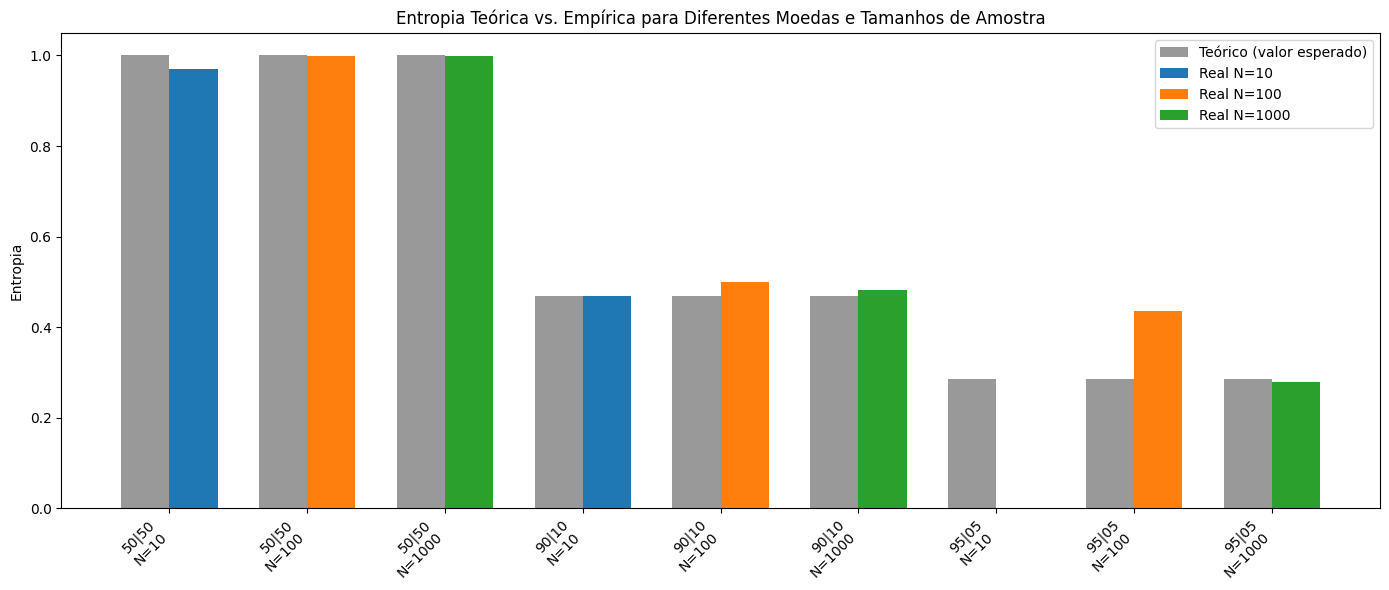

In [9]:
import matplotlib.pyplot as plt
import numpy as np

moedas = {
    "50|50": [0.50, 0.50],
    "90|10": [0.90, 0.10],
    "95|05": [0.95, 0.05]
}
iteracoes = [10, 100, 1000]

labels = []
teorico_vals = []
empirico_vals = []
cores_emp = []   #
n_por_moeda = len(iteracoes)

cor_por_N = {10: '#1f77b4', 100: '#ff7f0e', 1000: '#2ca02c'}

for nome, probs in moedas.items():
    ent_teorica = entropy(probs, "Vetor")
    for N in iteracoes:
        # rótulo: moeda + N
        labels.append(f"{nome}\nN={N}")
        teorico_vals.append(ent_teorica)
        freq_emp = jogada_moeda(probs, N)
        ent_emp = entropy(freq_emp, "Vetor")
        empirico_vals.append(ent_emp)
        cores_emp.append(cor_por_N[N])


x = np.arange(len(labels))  # posições dos grupos
largura = 0.35  # largura de cada barra

fig, ax = plt.subplots(figsize=(14, 6))

# Barra teórica (fixa, cinza escuro)
ax.bar(x - largura/2, teorico_vals, largura, label='Teórico', color='gray', alpha=0.8)
# Barra empírica (colorida por N)
ax.bar(x + largura/2, empirico_vals, largura, label='Empírico (N)', color=cores_emp)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Entropia')
ax.set_title('Entropia Teórica vs. Empírica para Diferentes Moedas e Tamanhos de Amostra')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=0.8, label='Teórico (valor esperado)'),
    Patch(facecolor=cor_por_N[10], label='Real N=10'),
    Patch(facecolor=cor_por_N[100], label='Real N=100'),
    Patch(facecolor=cor_por_N[1000], label='Real N=1000')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## Análise

 Independentemente do viés da moeda, as frequências observadas convergem para as probabilidades teóricas quando o número de lançamentos é suficientemente grande.

 Para as moedas normais a entropia varia de forma ficar próxima de $1$, que é quando os dois eventos são equiprováveis, isto é, a surpresa é grande.

 Já para as moedas viciadas as suas probabilidades reais passam a convergir para suas probabilidades teóricas, de forma que a cada vez que o número amostral aumenta, a probabilidade fica mais próxima da teórica. Ao passo de que a entropia dessas moedas vai diminuindo, ou seja, sua incerteza diminui o que pode ser considerado seu padrão pois um evento tem mais chance de ocorrer que o outro.

# Letra (C): Entropia


<img src="IMGS/img9.png" width="500">

<img src="IMGS/img10.png" width="500">

<img src="IMGS/img11.png" width="500">

<img src="IMGS/img12.png" width="500">

<img src="IMGS/img13.png" width="500">

<img src="IMGS/img14.png" width="500">

<img src="IMGS/img15.png" width="500">

<img src="IMGS/img16.png" width="500">

<img src="IMGS/img17.png" width="500">

## Raw logtis
valores brutos (não normalizados) que saem da última camada de uma rede neural antes de qualquer transformação em probabilidade.

## True Labels (one-hot encoding)
One-hot encoding é uma técnica de representação de variáveis categóricas em que cada classe é convertida em um vetor binário, contendo valor 1 na posição correspondente à classe e 0 nas demais posições.

Um exemplo  $(1, 0, 0)$.

## Função Softmax

A função de ativação Softmax função de ativação é uma função matemática que transforma um vetor de saídas brutas do modelo, conhecido como logits, em uma distribuição de probabilidade. Em termos mais simples, ele pega um conjunto de números e os converte em probabilidades que somam 1.

Ao contrário de algumas funções de ativação que operam em valores individuais de forma independente, o softmax trabalha em um vetor inteiro de valores, transformando-os coletivamente em uma distribuição de probabilidade em que todos os elementos somam exatamente 1.

No contexto das redes neurais, o softmax é normalmente aplicado à camada final de uma rede projetada para classificação multiclasse. Quando temos várias categorias possíveis e precisamos que nosso modelo indique a probabilidade de cada categoria, a função de ativação softmax é a escolha padrão. Para o problema apresentado a classificação é em três classes diferentes.

## Fórmula da Função de Ativação

$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$



A softmax funciona em três etapas principais:

1. **Exponencial**
   
   Cada valor $(x_i)$ é transformado usando a função exponencial:
   
   $$
   e^{x_i}
   $$
   
   Isso faz com que valores maiores cresçam mais rapidamente, destacando diferenças entre eles.

---

2. **Soma total**
   
   Todos os valores exponenciais são somados:
   
   $$
   \sum_{j=1}^{n} e^{x_j}
   $$
   
   Essa soma será usada para normalizar os resultados.

---

3. **Normalização**
   
   Cada valor exponencial é dividido pela soma total:
   
   $$
   \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
   $$
   
   Essa parte garante que todos os valores fiquem entre **0 e 1** e de que a soma das saídas seja **igual a 1**.

In [10]:
# Gerando semente aleatória do sistema
random.seed(time.time())

In [11]:
# Raw logits dados inicialmente
initial_logits = [[2.5, 0.3, 2.1],
                  [1.2, 2.4, 0.1],
                  [0.8, 0.5, 3.0]]

# Geração aleatória de Logits no intervalo de [0.1, 3.0]
# Cria 3 amostras e 3 classes
def generate_logits():
    raw_logits = [[random.uniform(0.1, 3.0) for _ in range(3)] for _ in range(3)]
    return raw_logits
# Exemplo de Raw logit (Definidos anteriormente)
# [[2.5, 0.3, 2.1], [1.2, 2.4, 0.1], [0.8, 0.5, 3.0]]

def softmax(x):
    return [[math.exp(j) / sum(math.exp(k) for k in linha) for j in linha] for linha in x]

In [12]:
# Esse é o One Hot Enconded
true_label = [ [1, 0, 0],
               [0, 1, 0],
               [0, 0, 1] ]

# Gerando os Logits e depois aplicando a Função de Ativação
logits = generate_logits()
probs = softmax(logits)

print("Logits:")
for linha in logits:
    print([round(x, 3) for x in linha])

print("\nProbabilidades (Softmax):")
for linha in probs:
    print([round(x, 4) for x in linha])

Logits:
[1.337, 2.355, 0.983]
[1.827, 2.875, 1.912]
[1.646, 0.445, 0.425]

Probabilidades (Softmax):
[0.2238, 0.6192, 0.157]
[0.2025, 0.5771, 0.2204]
[0.6268, 0.1884, 0.1847]


In [13]:
# Aplicando a Entropia Cruzada de Perda (Cross-Entropy Loss)
# CEL -> Cross Entropy Loss
def CEL(probabilidades, camadas):
    loss = 0
    for i in range(len(probabilidades)):
        line = probabilidades[i]
        label = camadas[i]
        for j in range (len(line)):
            loss += -(label[j]*math.log(line[j]))
    return loss/ len(probabilidades)

print(CEL(probs, true_label))

1.2452618670551694


In [14]:
test1 = softmax(initial_logits)
print(test1)
print(CEL(test1, true_label))

[[0.5614434742811651, 0.06220971019227488, 0.3763468155265599], [0.2149156624983984, 0.7135451280220689, 0.0715392094795326], [0.09288646023804283, 0.06881198219897001, 0.8383015575629872]]
0.36371038786807586


In [15]:
# Gerar Novos Raw Logits a partir de Logits dados
def gerador_gaussiano(logits, ruido):
    return [[random.gauss(mu = x, sigma = ruido) for x in linha] for linha in logits]

# Geração de fato:
sigma = 0.5
sequencias = []

sequencias.append(true_label)

for i in range(4):
    n_linha = gerador_gaussiano(true_label, sigma)
    sequencias.append(n_linha)

print("Logits | Loss")

for i, seq in enumerate(sequencias):
    probs_sm = softmax(seq)
    loss = CEL(probs_sm, true_label)

    print(f"{i:<10} {loss:.4f}")


print("\nLogits:")
for linha in sequencias:
    print([x for x in linha])

Logits | Loss
0          0.5514
1          0.3476
2          0.4284
3          0.4507
4          0.4767

Logits:
[[1, 0, 0], [0, 1, 0], [0, 0, 1]]
[[1.4713250168727912, 0.6338721437853156, -0.8071623731594706], [-0.5431958244722493, 1.290317779521143, 0.05282402718763575], [-0.46826187534586183, 0.40216095776303745, 2.0444971769407525]]
[[1.2841650212866733, -0.34140287855131257, -0.2722097841789193], [0.00021028388294841977, 0.709670030089401, -0.7298085997442881], [-0.18798316992868908, -0.12147245584395414, 1.2615926749002098]]
[[1.328789161978107, 0.010454817538729566, -0.19917507763502446], [0.23589070466130627, 1.2485299663367602, -0.2618542833798342], [0.5038220062717531, -1.2584693045302342, 1.102985315351331]]
[[1.3283411814751513, 0.34535860000773455, 0.16597628903697756], [0.18407068533386003, 0.8906952832016821, -0.5227754132925144], [-0.6986589731677991, 0.06610052646507801, 1.2998978925727949]]


In [16]:
# Processo de Evolução da Entropia
# Adição do Raws Logits iniciais e de outros 4:
historico = []
sequencias = [true_label]

for i in range(4):
    sequencias.append(gerador_gaussiano(initial_logits, sigma))

# Processo repetido 30 vezes
for j in range(30):
    avaliadas = []

    # Iterando sobre a matriz
    for k in sequencias:
        probability = softmax(k)
        entropia_H = entropy(probability, "Matriz")
        avaliadas.append((entropia_H, k))

    # ordenar por entropia (menor primeiro)
    avaliadas.sort(key=lambda x: x[0])

    # guardar melhor valor
    melhor_H = avaliadas[0][0]
    historico.append(melhor_H)

    print(f"Processo: {j+1:<2} | Entropia (H) = {melhor_H:.8f}")

    # manter só a melhor
    melhor_seq = avaliadas[0][1]

    # gerar novas a partir dela
    sequencias = [melhor_seq]
    for _ in range(4):
        sequencias.append(
            gerador_gaussiano(melhor_seq, sigma)
        )

Processo: 1  | Entropia (H) = 0.94808631
Processo: 2  | Entropia (H) = 0.77283316
Processo: 3  | Entropia (H) = 0.66234802
Processo: 4  | Entropia (H) = 0.51543991
Processo: 5  | Entropia (H) = 0.43915207
Processo: 6  | Entropia (H) = 0.35884397
Processo: 7  | Entropia (H) = 0.31658719
Processo: 8  | Entropia (H) = 0.31327711
Processo: 9  | Entropia (H) = 0.17913395
Processo: 10 | Entropia (H) = 0.17538657
Processo: 11 | Entropia (H) = 0.13180505
Processo: 12 | Entropia (H) = 0.10934011
Processo: 13 | Entropia (H) = 0.09984230
Processo: 14 | Entropia (H) = 0.07268662
Processo: 15 | Entropia (H) = 0.06415676
Processo: 16 | Entropia (H) = 0.06415676
Processo: 17 | Entropia (H) = 0.06060541
Processo: 18 | Entropia (H) = 0.03387819
Processo: 19 | Entropia (H) = 0.02612639
Processo: 20 | Entropia (H) = 0.01753350
Processo: 21 | Entropia (H) = 0.01753350
Processo: 22 | Entropia (H) = 0.01279423
Processo: 23 | Entropia (H) = 0.00841372
Processo: 24 | Entropia (H) = 0.00498954
Processo: 25 | E

## Análise

Pode-se notar que a medida que as iterações vão ocorrendo a entropia vai ficando cada vez menor, isto é, a surpresa está diminuindo e a cada vez que o valor diminui o resultado vai ficando cada vez mais certo. É observável que a primeira iteração tem grau de incerteza muito alto, que vai diminuindo gradativamente até chegar em valores próximos a 0.

# Letra (D): Entropia Cruzada

<img src="IMGS/img18.png" width="500">

<img src="IMGS/img19.png" width="500">

<img src="IMGS/img20.png" width="500">

<img src="IMGS/img21.png" width="500">

<img src="IMGS/img22.png" width="500">

<img src="IMGS/img23.png" width="500">

## Aplicando Softmax nos Logits

In [17]:
# Aplicando Softmax nos Logits
# Obs: Pequena adaptação pois minha função softmax não foi feita para funcionar com vetores, apenas com matrizes
imgs = [[2.0, 1.0, 5.0]]
ohc = [[1, 0, 0]]

# print(softmax(imgs))
# previsao = CEL(softmax(imgs), ohc)
# print(previsao)

act = softmax(imgs)
print(act)
print(cross_entropy(ohc[0], act[0]))

[[0.04661262257797389, 0.01714782554552039, 0.9362395518765058]]
3.0658839037574293


## Comparação
O resultado do uso da Função de Ativação Softmax no vetor $(2.0, 1.0, 5.0)$ resultou aproximadamente nas seguintes probabilidades $(0.0466, 0.0171, 0.9362)$ que em relação a distribuição real $(1, 0, 0)$, que está em one hot encoded. É possível notar que o modelo está muito confiante de que é da classe urbana, embora a imagem seja claramente de uma floresta, analisando as probabilidades obtidas pela Softmax denota-se que o modelo dá quase $94\%$ da probabilidade total para a mesma, ao passo de que sua probabilidade de ser uma floresta é menos que $0.05\%$.


 Ao se calcular a Entropia Cruzada (Cross Entropy), os resultados são cerca de $3.065$, isto é, o modelo está demasiadamente confiante no erro.

 ## Razão da Entropia Cruzada se simplificar para $( L = -\ln(q_{\text{floresta}}))$

Percebesse que a imagem com certeza é Floresta, então sua distribuição fica:

$p = (p_{\text{floresta}},\; p_{\text{água}},\; p_{\text{urbano}}) = (1,\; 0,\;0)$

Usando a fórmula de Entropia Cruzada (anteriormente citada) e modelando o problema:
$H(p, q) = - \left[ p_{\text{floresta}} \cdot \ln(q_{\text{floresta}}) + p_{\text{água}} \cdot \ln(q_{\text{água}}) + p_{\text{urbano}} \cdot \ln(q_{\text{urbano}}) \right]$

Observação: P é o modelo real, ao passo que Q é o modelo estimado.

Substituindo os valores de $P$ na fórmula, obtém-se:

$H(p, q) = - [ 1 \cdot \ln(q_{\text{floresta}}) + 0 \cdot \ln(q_{\text{água}}) + 0 \cdot \ln(q_{\text{urbano}}) ]$

E como ocorre a simplificação, pois há multiplicação por número $0$, resultando em:

$ H(p, q) = - \left[ \ln(q_{\text{floresta}}) + 0 + 0 \right] $

que por fim, neste caso específico simplifica-se totalmente para:

$ \boxed{H(p, q) = -\ln(q_{\text{floresta}})} $

## Novos Logits para o Modelo
Escolhendo arbitrariamente valores iniciais os logits são atualizados para reduzir a perda.

$ z_{\text{floresta}} = 2.5 $

$ z_{\text{agua}} = 1.0 $

$ z_{\text{urbano}} = 4.5 $



In [18]:
# Cálculo Atualizado

# Aplicando Softmax nos Logits atualizados
logits_lista = [[2.5, 1.0, 4.5], [3.0, 2.0, 2.5], [4.0, 2.5, 2.0], [4.5, 2.5, 2.0], [4.5, 2.0, 1.5], [5.0, 2.0, 2.0], [5.0, 1.5, 1.5], [5.5, 1.5, 1.0], [6.0, 1.5, 1.0],
                [6.0, 1.0, 1.0], [6.5, 1.0, 1.0],  [6.5, 0.5, 1.0], [7.0, 0.5, 0.5], [7.0, 0.25, 0.5], [7.25, 0.25, 0.25], [7.25, 0.25, 0.0], [7.5, 0.0, 0.0] ]

for logits in logits_lista:
    prob = softmax([logits])[0]
    loss = cross_entropy(ohc[0], prob)   # ohc[0] = [1,0,0]
    print(f"Logits: {logits}")
    print(f"Softmax: {prob}")
    print(f"Entropia Cruzada: {loss}\n")

Logits: [2.5, 1.0, 4.5]
Softmax: [0.11611453467414116, 0.025908654717401527, 0.8579768106084572]
Entropia Cruzada: 2.1531782071222882

Logits: [3.0, 2.0, 2.5]
Softmax: [0.506480391055654, 0.18632372322584756, 0.3071958857184984]
Entropia Cruzada: 0.6802696706417346

Logits: [4.0, 2.5, 2.0]
Softmax: [0.7361247243125939, 0.16425162762508783, 0.09962364806231834]
Entropia Cruzada: 0.3063557122291464

Logits: [4.5, 2.5, 2.0]
Softmax: [0.821409019465126, 0.11116562230242114, 0.06742535823245292]
Entropia Cruzada: 0.196734096919617

Logits: [4.5, 2.0, 1.5]
Softmax: [0.8834920740271944, 0.07252144568074775, 0.04398648029205784]
Entropia Cruzada: 0.12387295836936747

Logits: [5.0, 2.0, 2.0]
Softmax: [0.909442998512742, 0.045278500743629074, 0.045278500743629074]
Entropia Cruzada: 0.09492295642096073

Logits: [5.0, 1.5, 1.5]
Softmax: [0.9430450161270122, 0.028477491936493918, 0.028477491936493918]
Entropia Cruzada: 0.058641260343827266

Logits: [5.5, 1.5, 1.0]
Softmax: [0.9714164258223993, 0.01

## Análise de Resultados

A distribuição real é um vetor one hot encoded que representa a classe Floresta:

$ p = (1,\; 0,\; 0)$

Quando se analisa a entropia da distribuição real é percebe-se que é $0$, pois não há qualquer incerteza sobre o que é imagem, ela é de uma Floresta.

Posto isto:

A entropia cruzada entre a real $P$ e a prevista $Q$ é na seguinte fórmula:

$ H(p, q) = -\sum_{i} p_i \ln(q_i) $

Como $P$ é one hot encoded, a fórmula é simplificada e apenas o termo da classe objetivo fica presente:

$ H(p, q) = -\ln(q_{\text{floresta}}) $

Adiante, é perceptível que quanto mais o modelo melhora, maior se torna $ q_{\text{floresta}}$. E à medida que $q_{\text{floresta}}$ aproxima-se de $1$($100\%$ de probabilidade), a entropia cruzada aproxima-se de $0$, pois o modelo está se aproximando do previsto $Q$ e o erro entre os dois modelos está diminuindo.

Assim, a entropia cruzada converge para a entropia da distribuição real (que é zero).


# Letra (E): Valor Esperado

<img src="IMGS/img24.png" width="500">

<img src="IMGS/img25.png" width="500">




## Valor Esperado

O **valor esperado** é a média ponderada dos possíveis resultados de uma variável aleatória, considerando a probabilidade de cada um ocorrer. Ele representa o valor médio que se espera obter após muitas repetições do experimento.

---

### Fórmula:

$ E(X) = \sum x_i \cdot P(x_i) $

Multiplicar cada resultado possível pela sua probabilidade e realizar o somatório de tudo. O resultado é o "centro" da distribuição.



In [19]:
# Probabilidade (Relacionada a quem viu ou não o filme):
# Problema modelado especificamente para esse caso
# Sv: (Sim, viu) | Sn: (Não viu)
# P1: (Outcome de quem viu) | P2: (Outcome de quem não viu)
def probabilidade_telespectador(Sv, Nv, P1, P2, audiencia):
    total = Sv + Nv # Total de telespectadores do experimento

    probabilidade_s = (Sv / total) # Probabilidade de quem viu a mídia
    probabilidade_n = (Nv / total) # Probabilidade de quem não viu a mídia

    Valor_Esperado = (probabilidade_s * P1) + (probabilidade_n * P2)
    print(f"O Valor Esperado: {Valor_Esperado}")
    print(f"Ganho Esperado: {probabilidade_n * audiencia * P2}")
    print(f"Perda Esperada: {probabilidade_s * audiencia * P1}")


probabilidade_telespectador(37, 176, -1, 1, 100)

O Valor Esperado: 0.6525821596244132
Ganho Esperado: 82.62910798122066
Perda Esperada: -17.370892018779344


In [20]:
def simular_entrevista(Sv, Nv, N):
    # gera N amostras com base nas probabilidades
    resultados = random.choices([-1, 1], weights=[Sv, Nv], k=N)

    # valor esperado (média das amostras)
    return sum(resultados) / N


# dados (slide 26)
Sv = 37
Nv = 176

# outcomes (slide 51)
P1 = -1
P2 = 1

# normalizando para probabilidades
total = Sv + Nv
Sv = Sv / total
Nv = Nv / total

# valor esperado teórico
valor_esperado_T = Sv * P1 + Nv * P2

# número de repetições
iteracoes = [10, 100, 1000, 10000, 100000]

print(f"{'N':<10} {'Valor Esperado Prático':<30} {'Valor Esperado Teórico':<30}")

for N in iteracoes:
    VE_emp = simular_entrevista(Sv, Nv, N)
    print(f"{N:<10} {VE_emp:<30.4f} {valor_esperado_T:<30.4f}")

N          Valor Esperado Prático         Valor Esperado Teórico        
10         0.8000                         0.6526                        
100        0.6800                         0.6526                        
1000       0.5980                         0.6526                        
10000      0.6552                         0.6526                        
100000     0.6519                         0.6526                        


## Análise de Resultados

Nas iterações é perceptível que a medida que o número de pessoas entrevistadas aumenta, o valor esperado prático começa a tender para valores que flutuam em torno do Valor Esperado Teórico (Obtido por meio de cálculos anteriores). Em suma, À medida que o número de experimentos independentes ($N$) aumenta, a média amostral converge (em probabilidade) para o valor esperado teórico da distribuição. Isso quer dizer que caso houvesse a entrevista de 100 mil pessoas o valor seria mais aproximado do teórico.

